In [1]:
import numpy as np
import matplotlib.pyplot as pl
from soilice.src_soil import (
    model, thetaFun, CFun, KFun,
    thermalKfun, GCEFun, SFCslope, CBFun
    )
from soilice import writeDefaultPars
from numba import types
from numba.typed import Dict


In [2]:
def MakeDictFloat():
    d=Dict.empty(
    key_type=types.unicode_type,
    value_type=types.float64,)
    return d

In [3]:
# writeDefaultPars()

In [4]:
x=model()
x.readPars()
pars=MakeDictFloat()
const=MakeDictFloat()
for i in x.pars: pars[i]=x.pars[i]
for i in x.const: const[i]=x.const[i]

In [5]:
# Linear functions:
def thetaFunLinear(psi,pars):
    psim=pars['Tm']*334560/(9.81*273.15)
    Se=np.zeros(len(psi))
    Se[psi>psim]=(psi[psi>psim]-psim)/(0-psim)
    Se[psi>0]=1.
    return pars['thetaR']+(pars['thetaS']-pars['thetaR'])*Se

def CFunLinear(psi,pars):
    psim=pars['Tm']*334560/(9.81*273.15)
    C=np.zeros(len(psi))
    C[psi>psim]=(pars['thetaS']-pars['thetaR'])/(0-psim)
    C[psi>=0]=0.
    return C

# Thermal conductivity function
def thermalKfunLinear(psie,psif,T,pars,const):
    psim=pars['Tm']*334560/(9.81*273.15)
    Se=np.zeros(len(psie))
    Se[psif>psim]=(psif[psif>psim]-psim)/(0-psim)
    Se[psif>0]=1.
    kappa=Se*(pars['kappau']-pars['kappaf'])+pars['kappaf']
    return kappa

# Bulk heat capacity function
def CBFunLinear(psie,psif,pars,const):
    psim=pars['Tm']*334560/(9.81*273.15)
    Se=np.zeros(len(psie))
    Se[psif>psim]=(psif[psif>psim]-psim)/(0-psim)
    Se[psif>0]=1.
    CB=Se*(pars['cu']-pars['cf'])+pars['cf']
    return CB

# Original functions: 
def KFunLinear(psie,psif,pars,const):
    # Impedance model for K after Taylor and Luthin
    thetaL=thetaFunLinear(psif,pars)
    thetaT=thetaFunLinear(psie,pars)
    thetaI=const['rho_liq']/const['rho_ice']*(thetaT-thetaL)

    Se=(1+(psie*-pars['alpha'])**pars['n'])**(-pars['m'])
    Se[psie>0.]=1.0
    Ke=pars['Ks']*Se**pars['neta']*(1-(1-Se**(1/pars['m']))**pars['m'])**2

    K=Ke*10**(-10*thetaI)
    return K

# Slope function dtheta_L/dT
def SFCslopeLinear(psie,psif,pars,const):
    C=const['lambda_f']/const['g']/const['T0']
    dthdpsi=CFun(psif,pars)
    dthdT=C*dthdpsi
    return dthdT

# GCE
def GCEFunLinear(T,pars,const):
    psi=T*const['lambda_f']/(const['g']*const['T0'])
    psi[psi>0]=0.
    return psi


def get_th_kappa_cpb(psi,pars,const):
    psi=np.array([psi])
    thetaL=thetaFun(psi,pars)   # Total water content = liquid water content in thawed zone

    # Thawed properties:    
    kappa=thermalKfun(psi,psi,psi,pars,const)
    c_pb=CBFun(psi,psi,pars,const)

    # Frozen properties:
    kappa_f=thermalKfun(psi,np.array([-1e6]),psi,pars,const)
    c_pb_f=CBFun(np.array([0.]),np.array([-1e6]),pars,const)

    return thetaL,kappa,c_pb,kappa_f,c_pb_f

In [6]:
thetaL,kappa,c_pb,kappa_f,c_pb_f=get_th_kappa_cpb(0.,pars,const)
linpars={}
for i in x.pars: linpars[i]=x.pars[i]
linpars['Tm']=-0.08
linpars['kappau']=kappa
linpars['kappaf']=kappa_f
linpars['cu']=c_pb
linpars['cf']=c_pb_f
print(linpars)

{'thetaR': 0.218, 'thetaS': 0.52, 'alpha': 1.15, 'n': 2.03, 'eta': 0.5, 'Ks': 0.316, 'neta': 0.5, 'Ss': 1e-06, 'm': 0.5073891625615763, 'theta_org': 0.0, 'theta_mineral': 0.48, 'cp_soil': 850.0, 'cp_org': 580.0, 'kappa_soil': 250560.0, 'kappa_org': 21600.0, 'rho_soil': 2600.0, 'rho_org': 1300.0, 'q': 0.0, 'impedance': 0.0, 'Tm': -0.08, 'kappau': array([106542.41960905]), 'kappaf': array([223555.83499062]), 'cu': array([3234400.]), 'cf': array([2606240.35937801])}


In [7]:
n=200
psie=np.full(n,0.)
T=np.linspace(-1,0.1,n)
psif=GCEFun(T,pars,const)
psif=np.minimum(psif,psie)
thetaL=thetaFun(psif,pars)
thetaL_lin=thetaFunLinear(psif,linpars)
thetaT=thetaFun(psie,pars)

In [8]:
pars_sharp=pars.copy()
pars_sharp['alpha']=100.
pars_sharp['n']=10.
pars=pars_sharp.copy()

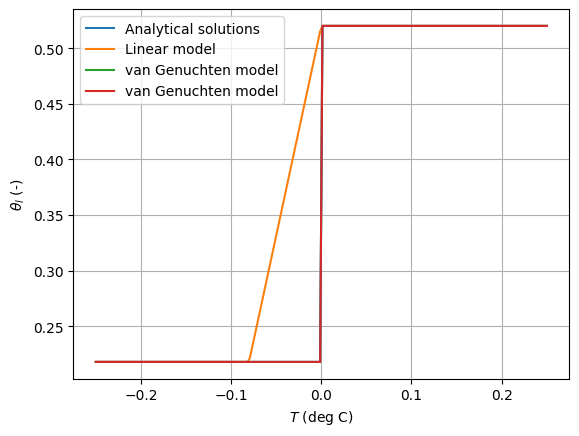

In [9]:
T=np.linspace(-0.25,+0.25,n)
psif=GCEFun(T,pars,const)
thL_N=np.full(n,linpars['thetaR'])
thL_N[T>0.]=linpars['thetaS']
thL_L=thetaFunLinear(psif,linpars)
thL_V=thetaFun(psif,pars)
thL_V2=thetaFun(psif,pars_sharp)

pl.plot(T,thL_N,label='Analytical solutions',zorder=3)
pl.plot(T,thL_L,label='Linear model',zorder=2)
pl.plot(T,thL_V,label='van Genuchten model',zorder=1)
pl.plot(T,thL_V2,label='van Genuchten model',zorder=4)

pl.grid()
pl.ylabel(r'$\theta_l$ (-)')
pl.xlabel(r'$T$ (deg C)')
pl.legend()

[Text(0, 0.1, ''),
 Text(0, 0.12000000000000001, ''),
 Text(0, 0.14, ''),
 Text(0, 0.16, ''),
 Text(0, 0.18, ''),
 Text(0, 0.2, ''),
 Text(0, 0.22, ''),
 Text(0, 0.24000000000000002, '')]

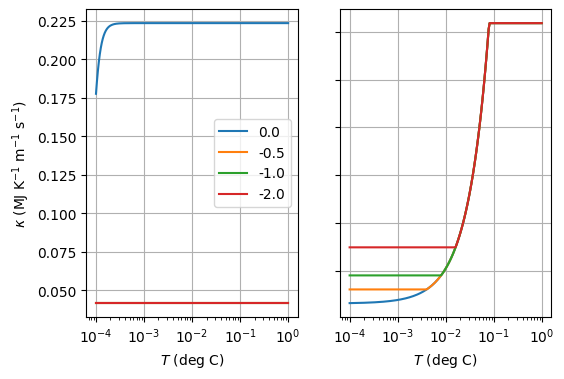

In [10]:
T=-np.logspace(-4,0,n)
log=True
psif=GCEFun(T,pars,const)
pl.figure(figsize=(6,4))
pl.subplot(1,2,1)
for psie in np.array([0,-.5,-1,-2]):
    pl.plot(-T,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
# pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.legend()

pl.subplot(1,2,2)
for psie in np.array([0,-.5,-1,-2]):
    pl.plot(-T,thermalKfunLinear(np.full(n,psie),np.minimum(psif,psie),T,linpars,x.const)/1e6)
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
# pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)

(0.017894189500603185, 0.08900970825135453)

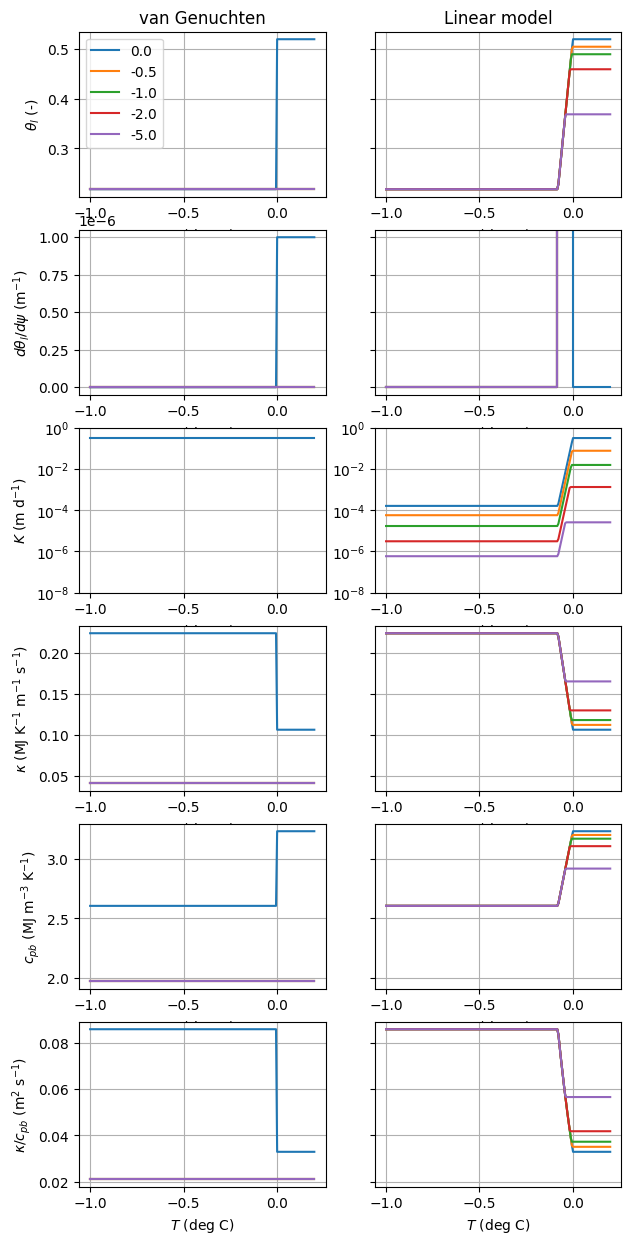

In [11]:
log=False
if log: 
    T=-np.logspace(-4,0,n)
    psif=GCEFun(T,pars,const)
else:
    T=np.linspace(-1,0.2,n)
    psif=GCEFun(T,pars,const)
    T=-T
psi_arr=np.array([0,-.5,-1,-2,-5])

pl.figure(figsize=(7,15))

pl.subplot(6,2,1)
for psie in psi_arr:
    pl.plot(-T,thetaFun(np.minimum(psif,psie),pars),label=str(psie))
pl.grid()
pl.ylabel(r'$\theta_l$ (-)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.legend()
pl.title('van Genuchten')
yl=pl.gca().get_ylim()

pl.subplot(6,2,2)
for psie in psi_arr:
    pl.plot(-T,thetaFunLinear(np.minimum(psif,psie),linpars))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.title('Linear model')
pl.ylim(yl)

pl.subplot(6,2,3)
for psie in psi_arr:
    pl.plot(-T,CFun(np.minimum(psif,psie),pars),label=str(psie))
pl.grid()
pl.ylabel(r'$d\theta_l/d\psi$ (m$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
yl=pl.gca().get_ylim()

pl.subplot(6,2,4)
for psie in psi_arr:
    pl.plot(-T,CFunLinear(np.minimum(psif,psie),linpars))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.ylim(yl)

pl.subplot(6,2,5)
for psie in psi_arr:
    pl.plot(-T,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$K$ (m d$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-8,1)


pl.subplot(6,2,6)
for psie in psi_arr:
    pl.plot(-T,KFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# pl.ylim(yl)
pl.ylim(1e-8,1)


pl.subplot(6,2,7)
for psie in psi_arr:
    pl.plot(-T,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,8)
for psie in psi_arr:
    pl.plot(-T,thermalKfunLinear(np.full(n,psie),np.minimum(psif,psie),T,linpars,x.const)/1e6)
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

pl.subplot(6,2,9)
for psie in psi_arr:
    pl.plot(-T,CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$c_{pb}$ (MJ m$^{-3}$ K$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,10)
for psie in psi_arr:
    pl.plot(-T,CBFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const)/1e6)
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

pl.subplot(6,2,11)
for psie in psi_arr:
    pl.plot(-T,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa/c_{pb}$ (m$^2$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,12)
for psie in psi_arr:
    pl.plot(-T,thermalKfunLinear(np.full(n,psie),np.minimum(psif,psie),T,linpars,x.const)/CBFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

# pl.savefig('details.png',dpi=300)

/var/folders/sj/cl82w3k514b6j7vdd7_g_zv40000gq/T/ipykernel_76702/787040286.py:41: RuntimeWarning: invalid value encountered in power
  Se=(1+(psie*-pars['alpha'])**pars['n'])**(-pars['m'])


(0.01789418950060304, 0.08900970825135453)

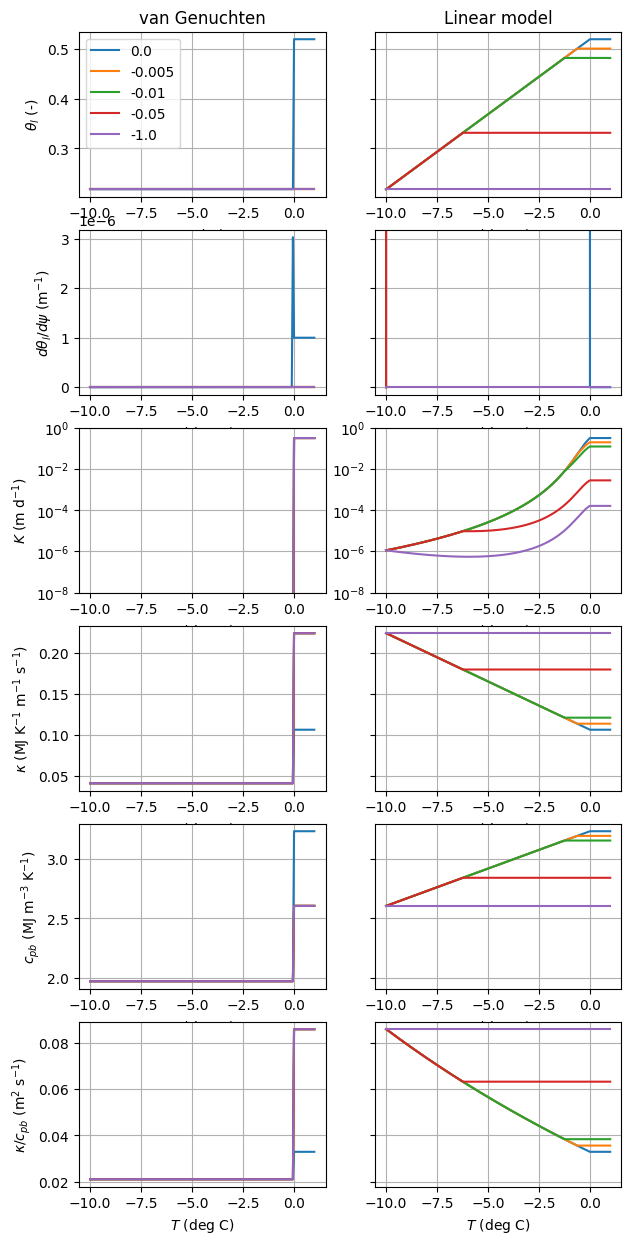

In [12]:
log=False
if log: 
    psie=np.logspace(-2,2,n)
    xx=-psie
else:
    psie=np.linspace(-10,1,n)
    xx=psie

Tarr=np.array([0,-.005,-.01,-0.05,-1])
pl.figure(figsize=(7,15))

pl.subplot(6,2,1)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thetaFun(np.minimum(psif,psie),pars),label=str(T))
pl.grid()
pl.ylabel(r'$\theta_l$ (-)')
pl.xlabel(r'$\psi_e$ (m)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.legend()
pl.title('van Genuchten')
yl=pl.gca().get_ylim()

pl.subplot(6,2,2)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thetaFunLinear(np.minimum(psif,psie),linpars))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.title('Linear model')
pl.ylim(yl)

pl.subplot(6,2,3)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,CFun(np.minimum(psif,psie),pars),label=str(psie))
pl.grid()
pl.ylabel(r'$d\theta_l/d\psi$ (m$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
yl=pl.gca().get_ylim()

pl.subplot(6,2,4)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,CFunLinear(np.minimum(psif,psie),linpars))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.ylim(yl)

pl.subplot(6,2,5)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$K$ (m d$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-8,1)

pl.subplot(6,2,6)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,KFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# pl.ylim(yl)
pl.ylim(1e-8,1)

pl.subplot(6,2,7)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,8)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfunLinear(np.full(n,psie),np.minimum(psif,psie),T,linpars,x.const)/1e6)
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

pl.subplot(6,2,9)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$c_{pb}$ (MJ m$^{-3}$ K$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,10)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,CBFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const)/1e6)
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

pl.subplot(6,2,11)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa/c_{pb}$ (m$^2$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(6,2,12)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfunLinear(np.full(n,psie),np.minimum(psif,psie),T,linpars,x.const)/CBFunLinear(np.full(n,psie),np.minimum(psif,psie),linpars,x.const))
pl.grid()
# pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
pl.gca().set_yticklabels('')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(yl)

# pl.savefig('details2.png',dpi=300)